# ILN05 - Modelos Clasicos (TF-IDF + Regresion Logistica)

Este notebook presenta un enfoque clasico de clasificacion multilabel de generos cinematograficos a partir de texto.

## Objetivo
Entrenar y comparar modelos basados en TF-IDF, seleccionar la mejor configuracion y generar el archivo final de predicciones para entrega.

## 1) Entorno y carga de datos

Se importan librerias, se descomprime el dataset y se cargan los archivos de train/test.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    precision_recall_fscore_support,
    classification_report,
    f1_score
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion

with zipfile.ZipFile("Dataset-Movies.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
train_df = pd.read_csv("dataset_train.csv")
test_df = pd.read_csv("dataset_test.csv")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2) Exploracion inicial y analisis de etiquetas

Revision basica de estructura del dataset y distribucion de generos para entender el problema multilabel.

In [5]:
display(train_df.shape)
display(train_df.columns)
display(train_df.isna().sum())
train_df.head()

(8475, 3)

Index(['movie_name', 'genre', 'description'], dtype='str')

movie_name     0
genre          0
description    0
dtype: int64

,movie_name,genre,description
0,Silent Hill,"Horror, Mystery","Rose, a desperate mother takes her adopted dau..."
1,Breaking the Waves,"Drama, Romance","In a small and conservative Scottish village, ..."
2,Wind Chill,"Drama, Horror, Thriller",Two college students share a ride home for the...
3,Godmothered,"Family, Fantasy, Comedy",A young and unskilled fairy godmother that ven...
4,Donkey Skin,"Fantasy, Comedy, Music, Romance",A fairy godmother helps a princess disguise he...


  Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 58.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 89.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Drama              3957
Comedy             3046
Thriller           2289
Action             1974
Romance            1483
Adventure          1429
Crime              1362
Horror             1159
Science Fiction    1004
Family              969
Fantasy             962
Mystery             813
Animation           805
History             442
War                 293
Music               250
Western             130
TV Movie            101
dtype: int64

Número de géneros: 18
Media de géneros por película: 2.6510914454277286
Máximo de géneros en una película: 9
Mínimo de géneros en una película: 1


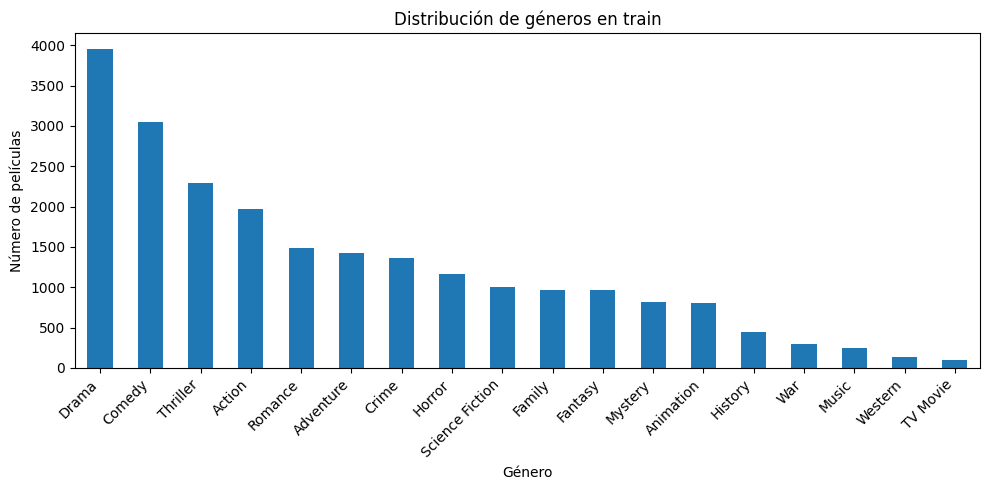

In [ ]:
train_df["genre_list"] = train_df["genre"].apply(
    lambda x: [g.strip() for g in x.split(",")]
)

genre_counter = Counter()

for genres in train_df["genre_list"]:
    genre_counter.update(genres)

genre_counts = pd.Series(genre_counter).sort_values(ascending=False)

display(genre_counts)
print("Número de géneros:", len(genre_counts))
print("Media de géneros por película:", train_df["genre_list"].apply(len).mean())
print("Máximo de géneros en una película:", train_df["genre_list"].apply(len).max())
print("Mínimo de géneros en una película:", train_df["genre_list"].apply(len).min())

plt.figure(figsize=(10, 5))
genre_counts.plot(kind="bar")
plt.title("Distribución de géneros en train")
plt.ylabel("Número de películas")
plt.xlabel("Género")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

genre_list
1    1187
2    2610
3    3144
4    1137
5     324
6      55
7      14
8       3
9       1
Name: count, dtype: int64

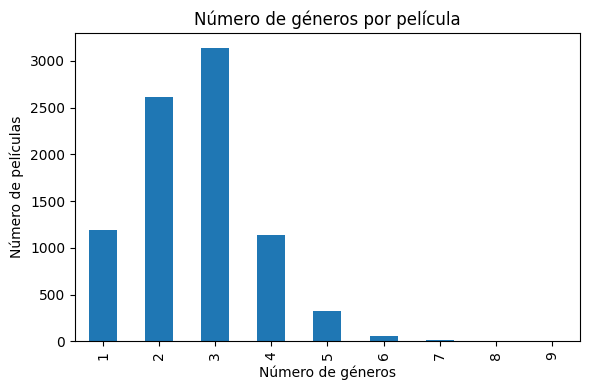

In [8]:
num_genres_per_movie = train_df["genre_list"].apply(len)

display(num_genres_per_movie.value_counts().sort_index())

plt.figure(figsize=(6, 4))
num_genres_per_movie.value_counts().sort_index().plot(kind="bar")
plt.title("Número de géneros por película")
plt.xlabel("Número de géneros")
plt.ylabel("Número de películas")
plt.tight_layout()
plt.show()

In [ ]:
mlb = MultiLabelBinarizer()

# Codificacion multilabel: cada genero se convierte en una columna binaria.
Y = mlb.fit_transform(train_df["genre_list"])

genres = list(mlb.classes_)

print("Géneros:")
print(genres)

print("\nShape de Y:")
print(Y.shape)

print("\nPrimera película:")
print(train_df.loc[0, "movie_name"])
print("Géneros originales:", train_df.loc[0, "genre"])
print("Vector binario:", Y[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 24.9 MB/s  0:00:000.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 42.9 MB/s  0:00:00 41.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Géneros:
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Shape de Y:
(8475, 18)

Primera película:
Silent Hill
Géneros originales: Horror, Mystery
Vector binario: [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0]


## 3) Ingenieria de texto y particion train/dev

Se construyen variantes de texto de entrada y se define la funcion comun de metricas para comparar modelos.

In [10]:
train_df["text_description"] = train_df["description"].fillna("")

test_df["text_description"] = test_df["description"].fillna("")

train_df["text_title_description"] = (
    "Title: " + train_df["movie_name"].fillna("") +
    ". Plot: " + train_df["description"].fillna("")
)

test_df["text_title_description"] = (
    "Title: " + test_df["movie_name"].fillna("") +
    ". Plot: " + test_df["description"].fillna("")
)

train_df["text_title_weighted"] = (
    train_df["movie_name"].fillna("") + ". " +
    train_df["movie_name"].fillna("") + ". " +
    train_df["description"].fillna("")
)

test_df["text_title_weighted"] = (
    test_df["movie_name"].fillna("") + ". " +
    test_df["movie_name"].fillna("") + ". " +
    test_df["description"].fillna("")
)

display(train_df[[
    "movie_name",
    "genre",
    "text_description",
    "text_title_description",
    "text_title_weighted"
]].head(2))

,movie_name,genre,text_description,text_title_description,text_title_weighted
0,Silent Hill,"Horror, Mystery","Rose, a desperate mother takes her adopted dau...","Title: Silent Hill. Plot: Rose, a desperate mo...","Silent Hill. Silent Hill. Rose, a desperate mo..."
1,Breaking the Waves,"Drama, Romance","In a small and conservative Scottish village, ...",Title: Breaking the Waves. Plot: In a small an...,Breaking the Waves. Breaking the Waves. In a s...


In [ ]:
TEXT_COL = "text_title_description"

X = train_df[TEXT_COL]
movie_names = train_df["movie_name"]

X_train, X_dev, y_train, y_dev, names_train, names_dev = train_test_split(
    X,
    Y,
    movie_names,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_dev:", X_dev.shape)
print("y_train:", y_train.shape)
print("y_dev:", y_dev.shape)

train_genre_counts = pd.Series(y_train.sum(axis=0), index=genres).sort_values(ascending=False)
dev_genre_counts = pd.Series(y_dev.sum(axis=0), index=genres).sort_values(ascending=False)

comparison = pd.DataFrame({
    "train_count": train_genre_counts,
    "dev_count": dev_genre_counts,
    "total_count": pd.Series(Y.sum(axis=0), index=genres)
}).sort_values("total_count", ascending=False)

display(comparison)


def compute_metrics(y_true, y_pred):
    # Metricas globales para comparar modelos de forma homogénea.
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    hl = hamming_loss(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1,
        "hamming_loss": hl,
        "avg_labels_pred": y_pred.sum(axis=1).mean(),
        "avg_labels_true": y_true.sum(axis=1).mean()
    }

X_train: (6780,)
X_dev: (1695,)
y_train: (6780, 18)
y_dev: (1695, 18)


,train_count,dev_count,total_count
Drama,3168,789,3957
Comedy,2421,625,3046
Thriller,1818,471,2289
Action,1563,411,1974
Romance,1215,268,1483
Adventure,1151,278,1429
Crime,1089,273,1362
Horror,928,231,1159
Science Fiction,791,213,1004
Family,791,178,969


## 4) Baselines y primeras comparaciones

Se comparan varios modelos clasicos (NB, Logistic Regression, SVC) sobre la misma particion para tener una referencia consistente.

In [ ]:
baseline_nb = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="word",
        max_features=5000,
        lowercase=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        MultinomialNB()
    ))
])

baseline_nb.fit(X_train, y_train)

y_pred_nb = baseline_nb.predict(X_dev)

metrics_nb = compute_metrics(y_dev, y_pred_nb)
display(metrics_nb)

print(classification_report(
    y_dev,
    y_pred_nb,
    target_names=genres,
    zero_division=0
))

{'accuracy': 0.11799410029498525,
 'precision': 0.5190476024129169,
 'recall': 0.5238844524749902,
 'f1_macro': 0.511892656715306,
 'hamming_loss': 0.11737135365453949,
 'avg_labels_pred': np.float64(2.8507374631268436),
 'avg_labels_true': np.float64(2.6601769911504425)}

                 precision    recall  f1-score   support

         Action       0.67      0.77      0.72       411
      Adventure       0.52      0.62      0.57       278
      Animation       0.56      0.54      0.55       172
         Comedy       0.69      0.68      0.68       625
          Crime       0.56      0.66      0.61       273
          Drama       0.66      0.70      0.68       789
         Family       0.59      0.59      0.59       178
        Fantasy       0.46      0.43      0.44       189
        History       0.40      0.39      0.40        90
         Horror       0.60      0.62      0.61       231
          Music       0.58      0.36      0.44        53
        Mystery       0.45      0.44      0.44       163
        Romance       0.47      0.68      0.55       268
Science Fiction       0.62      0.68      0.65       213
       TV Movie       0.00      0.00      0.00        17
       Thriller       0.63      0.70      0.66       471
            War       0.48    

In [ ]:
tfidf_logreg = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            solver="liblinear"
        )
    ))
])

tfidf_logreg.fit(X_train, y_train)

y_pred_lr = tfidf_logreg.predict(X_dev)

metrics_lr = compute_metrics(y_dev, y_pred_lr)
display(metrics_lr)

print(classification_report(
    y_dev,
    y_pred_lr,
    target_names=genres,
    zero_division=0
))



{'accuracy': 0.128023598820059,
 'precision': 0.5674489269292575,
 'recall': 0.5729639202264586,
 'f1_macro': 0.5615820706089102,
 'hamming_loss': 0.11261881350376926,
 'avg_labels_pred': np.float64(2.882005899705015),
 'avg_labels_true': np.float64(2.6601769911504425)}

                 precision    recall  f1-score   support

         Action       0.68      0.78      0.73       411
      Adventure       0.50      0.62      0.55       278
      Animation       0.62      0.55      0.59       172
         Comedy       0.67      0.70      0.68       625
          Crime       0.61      0.66      0.63       273
          Drama       0.68      0.70      0.69       789
         Family       0.60      0.64      0.62       178
        Fantasy       0.47      0.49      0.48       189
        History       0.36      0.40      0.38        90
         Horror       0.64      0.71      0.67       231
          Music       0.65      0.49      0.56        53
        Mystery       0.42      0.50      0.45       163
        Romance       0.50      0.68      0.58       268
Science Fiction       0.66      0.68      0.67       213
       TV Movie       0.25      0.06      0.10        17
       Thriller       0.64      0.71      0.67       471
            War       0.61    

In [ ]:
tfidf_svc = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        )
    ))
])

tfidf_svc.fit(X_train, y_train)

y_pred_svc = tfidf_svc.predict(X_dev)

metrics_svc = compute_metrics(y_dev, y_pred_svc)
display(metrics_svc)

print(classification_report(
    y_dev,
    y_pred_svc,
    target_names=genres,
    zero_division=0
))



{'accuracy': 0.1486725663716814,
 'precision': 0.6635945112908401,
 'recall': 0.47461986130258477,
 'f1_macro': 0.5248628383025379,
 'hamming_loss': 0.10904621435594887,
 'avg_labels_pred': np.float64(2.392920353982301),
 'avg_labels_true': np.float64(2.6601769911504425)}

                 precision    recall  f1-score   support

         Action       0.71      0.71      0.71       411
      Adventure       0.56      0.55      0.55       278
      Animation       0.75      0.48      0.58       172
         Comedy       0.68      0.65      0.67       625
          Crime       0.61      0.58      0.60       273
          Drama       0.68      0.66      0.67       789
         Family       0.67      0.54      0.60       178
        Fantasy       0.55      0.40      0.46       189
        History       0.47      0.23      0.31        90
         Horror       0.65      0.56      0.60       231
          Music       0.64      0.30      0.41        53
        Mystery       0.50      0.34      0.41       163
        Romance       0.53      0.56      0.54       268
Science Fiction       0.71      0.60      0.65       213
       TV Movie       1.00      0.06      0.11        17
       Thriller       0.64      0.63      0.64       471
            War       0.72    

In [19]:
tfidf_logreg_no_stop = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words=None
    )),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            solver="liblinear"
        )
    ))
])

tfidf_logreg_no_stop.fit(X_train, y_train)

y_pred_lr_no_stop = tfidf_logreg_no_stop.predict(X_dev)

metrics_lr_no_stop = compute_metrics(y_dev, y_pred_lr_no_stop)
display(metrics_lr_no_stop)

print(classification_report(
    y_dev,
    y_pred_lr_no_stop,
    target_names=genres,
    zero_division=0
))

{'accuracy': 0.12212389380530973,
 'precision': 0.5945118240205007,
 'recall': 0.5312140920180428,
 'f1_macro': 0.5372001414158928,
 'hamming_loss': 0.11609308423467715,
 'avg_labels_pred': np.float64(2.7887905604719765),
 'avg_labels_true': np.float64(2.6601769911504425)}

                 precision    recall  f1-score   support

         Action       0.65      0.75      0.70       411
      Adventure       0.52      0.67      0.59       278
      Animation       0.61      0.53      0.57       172
         Comedy       0.66      0.68      0.67       625
          Crime       0.59      0.62      0.60       273
          Drama       0.69      0.68      0.69       789
         Family       0.63      0.60      0.61       178
        Fantasy       0.44      0.41      0.42       189
        History       0.36      0.40      0.38        90
         Horror       0.59      0.62      0.61       231
          Music       0.79      0.36      0.49        53
        Mystery       0.44      0.45      0.44       163
        Romance       0.47      0.63      0.54       268
Science Fiction       0.66      0.66      0.66       213
       TV Movie       0.50      0.06      0.11        17
       Thriller       0.62      0.69      0.65       471
            War       0.61    

In [20]:
TEXT_COL = "text_title_weighted"

X = train_df[TEXT_COL]
movie_names = train_df["movie_name"]

X_train_w, X_dev_w, y_train_w, y_dev_w, names_train_w, names_dev_w = train_test_split(
    X,
    Y,
    movie_names,
    test_size=0.2,
    random_state=42
)

print("X_train_w:", X_train_w.shape)
print("X_dev_w:", X_dev_w.shape)
print("y_train_w:", y_train_w.shape)
print("y_dev_w:", y_dev_w.shape)

tfidf_logreg_weighted_title = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            solver="liblinear"
        )
    ))
])

tfidf_logreg_weighted_title.fit(X_train_w, y_train_w)

y_pred_lr_weighted_title = tfidf_logreg_weighted_title.predict(X_dev_w)

metrics_lr_weighted_title = compute_metrics(y_dev_w, y_pred_lr_weighted_title)
metrics_lr_weighted_title

print(classification_report(
    y_dev_w,
    y_pred_lr_weighted_title,
    target_names=genres,
    zero_division=0
))

X_train_w: (6780,)
X_dev_w: (1695,)
y_train_w: (6780, 18)
y_dev_w: (1695, 18)
                 precision    recall  f1-score   support

         Action       0.68      0.77      0.73       411
      Adventure       0.51      0.62      0.56       278
      Animation       0.62      0.56      0.59       172
         Comedy       0.67      0.70      0.68       625
          Crime       0.59      0.67      0.63       273
          Drama       0.69      0.70      0.69       789
         Family       0.58      0.67      0.62       178
        Fantasy       0.46      0.50      0.48       189
        History       0.35      0.37      0.36        90
         Horror       0.62      0.72      0.67       231
          Music       0.64      0.47      0.54        53
        Mystery       0.43      0.49      0.46       163
        Romance       0.50      0.68      0.57       268
Science Fiction       0.66      0.66      0.66       213
       TV Movie       0.25      0.06      0.10        17
       Th

In [22]:
display(metrics_lr_weighted_title)

TEXT_COL = "text_title_description"

X = train_df[TEXT_COL]
movie_names = train_df["movie_name"]

X_train, X_dev, y_train, y_dev, names_train, names_dev = train_test_split(
    X,
    Y,
    movie_names,
    test_size=0.2,
    random_state=42
)

results_c = []

for C in [0.3, 0.5, 1.0, 2.0, 4.0]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            max_features=50000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=C,
                solver="liblinear"
            )
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)

    metrics = compute_metrics(y_dev, y_pred)
    metrics["C"] = C
    results_c.append(metrics)

results_c_df = pd.DataFrame(results_c).sort_values("f1_macro", ascending=False)
display(results_c_df)

{'accuracy': 0.11976401179941003,
 'precision': 0.5582385145991589,
 'recall': 0.5721348224271803,
 'f1_macro': 0.5568826662009555,
 'hamming_loss': 0.11379875450671911,
 'avg_labels_pred': np.float64(2.9008849557522125),
 'avg_labels_true': np.float64(2.6601769911504425)}

,accuracy,precision,recall,f1_macro,hamming_loss,avg_labels_pred,avg_labels_true,C
2,0.128024,0.567449,0.572964,0.561582,0.112619,2.882006,2.660177,1.0
3,0.135693,0.584654,0.554670,0.561014,0.110324,2.743953,2.660177,2.0
1,0.114454,0.547996,0.588370,0.560289,0.116486,2.997640,2.660177,0.5
0,0.111504,0.538725,0.594851,0.557875,0.118551,3.057227,2.660177,0.3
4,0.147493,0.604597,0.533121,0.556658,0.108948,2.602360,2.660177,4.0


## 5) Ajustes de hiperparametros

Se prueban variaciones de C, max_features y combinaciones de n-gramas para mejorar el F1 macro.

In [ ]:
results_features = []

for max_features in [20000, 50000, 100000, 150000]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            max_features=max_features,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=1.0,
                solver="liblinear"
            )
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)

    metrics = compute_metrics(y_dev, y_pred)
    metrics["max_features"] = max_features
    results_features.append(metrics)

results_features_df = pd.DataFrame(results_features).sort_values("f1_macro", ascending=False)
display(results_features_df)

,accuracy,precision,recall,f1_macro,hamming_loss,avg_labels_pred,avg_labels_true,max_features
1,0.128024,0.567449,0.572964,0.561582,0.112619,2.882006,2.660177,50000
2,0.128024,0.567449,0.572964,0.561582,0.112619,2.882006,2.660177,100000
3,0.128024,0.567449,0.572964,0.561582,0.112619,2.882006,2.660177,150000
0,0.126844,0.555028,0.575835,0.557624,0.114454,2.918584,2.660177,20000


In [ ]:
tfidf_word_char_logreg = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            max_features=50000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        ))
    ])),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            solver="liblinear"
        )
    ))
])

tfidf_word_char_logreg.fit(X_train, y_train)

y_pred_word_char = tfidf_word_char_logreg.predict(X_dev)

metrics_word_char = compute_metrics(y_dev, y_pred_word_char)
display(metrics_word_char)

print(classification_report(
    y_dev,
    y_pred_word_char,
    target_names=genres,
    zero_division=0
))

{'accuracy': 0.13451327433628318,
 'precision': 0.5748053955506943,
 'recall': 0.5759303421701591,
 'f1_macro': 0.5688476888969681,
 'hamming_loss': 0.11055391674860701,
 'avg_labels_pred': np.float64(2.8283185840707965),
 'avg_labels_true': np.float64(2.6601769911504425)}

                 precision    recall  f1-score   support

         Action       0.68      0.78      0.73       411
      Adventure       0.53      0.63      0.58       278
      Animation       0.67      0.58      0.62       172
         Comedy       0.68      0.72      0.70       625
          Crime       0.60      0.66      0.63       273
          Drama       0.69      0.68      0.68       789
         Family       0.61      0.63      0.62       178
        Fantasy       0.49      0.50      0.49       189
        History       0.40      0.39      0.39        90
         Horror       0.62      0.71      0.66       231
          Music       0.66      0.47      0.55        53
        Mystery       0.47      0.52      0.49       163
        Romance       0.51      0.65      0.57       268
Science Fiction       0.64      0.67      0.65       213
       TV Movie       0.25      0.06      0.10        17
       Thriller       0.63      0.69      0.66       471
            War       0.64    

In [ ]:
y_score_word_char = tfidf_word_char_logreg.predict_proba(X_dev)

print(y_score_word_char.shape)
print(y_score_word_char[:2])


def find_best_thresholds(y_true, y_scores, genres, thresholds=np.arange(0.05, 0.96, 0.01)):
    # Busca el umbral que maximiza F1 por cada clase de forma independiente.
    best_thresholds = []
    best_f1s = []

    for j, genre in enumerate(genres):
        best_t = 0.5
        best_f1 = 0.0

        for t in thresholds:
            y_pred_j = (y_scores[:, j] >= t).astype(int)
            f1 = f1_score(y_true[:, j], y_pred_j, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        best_thresholds.append(best_t)
        best_f1s.append(best_f1)

    return np.array(best_thresholds), np.array(best_f1s)


best_thresholds, best_f1s = find_best_thresholds(
    y_dev,
    y_score_word_char,
    genres
)

thresholds_df = pd.DataFrame({
    "genre": genres,
    "best_threshold": best_thresholds,
    "best_dev_f1_for_class": best_f1s,
    "support_dev": y_dev.sum(axis=0)
}).sort_values("best_threshold")

display(thresholds_df)

y_pred_word_char_thr = (y_score_word_char >= best_thresholds).astype(int)

metrics_word_char_thr = compute_metrics(y_dev, y_pred_word_char_thr)
metrics_word_char_thr

print(classification_report(
    y_dev,
    y_pred_word_char_thr,
    target_names=genres,
    zero_division=0
))

(1695, 18)
[[0.17547815 0.14071433 0.17257827 0.30560951 0.22379667 0.22218625
  0.11569398 0.53879971 0.07759887 0.81171074 0.04519821 0.36257548
  0.18232008 0.12461728 0.15364549 0.57180671 0.03416111 0.02830025]
 [0.14176326 0.06627228 0.06959603 0.59985913 0.28571543 0.69307362
  0.21261644 0.10600103 0.061658   0.18156513 0.13531275 0.29400804
  0.41181519 0.05709603 0.06104613 0.33789007 0.04004891 0.28590468]]


,genre,best_threshold,best_dev_f1_for_class,support_dev
14,TV Movie,0.29,0.205128,17
17,Western,0.38,0.580645,27
10,Music,0.40,0.568627,53
8,History,0.40,0.424242,90
5,Drama,0.42,0.723735,789
7,Fantasy,0.43,0.505495,189
16,War,0.43,0.646154,61
1,Adventure,0.43,0.591631,278
3,Comedy,0.43,0.706704,625
6,Family,0.44,0.639423,178


                 precision    recall  f1-score   support

         Action       0.69      0.78      0.73       411
      Adventure       0.49      0.74      0.59       278
      Animation       0.69      0.57      0.62       172
         Comedy       0.63      0.81      0.71       625
          Crime       0.58      0.71      0.64       273
          Drama       0.64      0.83      0.72       789
         Family       0.56      0.75      0.64       178
        Fantasy       0.43      0.61      0.51       189
        History       0.35      0.54      0.42        90
         Horror       0.60      0.75      0.67       231
          Music       0.59      0.55      0.57        53
        Mystery       0.44      0.55      0.49       163
        Romance       0.48      0.72      0.58       268
Science Fiction       0.77      0.60      0.67       213
       TV Movie       0.18      0.24      0.21        17
       Thriller       0.60      0.77      0.67       471
            War       0.61    

## 6) Ajuste de umbrales por clase

En lugar de usar un umbral fijo de 0.5 para todos los generos, se calcula el mejor umbral por clase en el conjunto de desarrollo.

In [26]:
display(metrics_word_char_thr)

{'accuracy': 0.10619469026548672,
 'precision': 0.5470339118002618,
 'recall': 0.6585954066069619,
 'f1_macro': 0.5922833136226394,
 'hamming_loss': 0.11638806948541462,
 'avg_labels_pred': np.float64(3.338053097345133),
 'avg_labels_true': np.float64(2.6601769911504425)}

In [ ]:
def evaluate_with_thresholds(model, X_dev, y_dev, genres, show_report=False):
    y_scores = model.predict_proba(X_dev)

    best_thresholds, best_f1s = find_best_thresholds(
        y_dev,
        y_scores,
        genres
    )

    y_pred_thr = (y_scores >= best_thresholds).astype(int)

    metrics = compute_metrics(y_dev, y_pred_thr)

    thresholds_df = pd.DataFrame({
        "genre": genres,
        "best_threshold": best_thresholds,
        "best_dev_f1_for_class": best_f1s,
        "support_dev": y_dev.sum(axis=0)
    }).sort_values("genre")

    if show_report:
        print(classification_report(
            y_dev,
            y_pred_thr,
            target_names=genres,
            zero_division=0
        ))

    return metrics, thresholds_df, y_pred_thr, y_scores

In [28]:
results_ngrams = []

for word_ngram in [(1,1), (1,2), (1,3)]:
    model = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="word",
                ngram_range=word_ngram,
                min_df=2,
                max_df=0.9,
                max_features=50000,
                sublinear_tf=True,
                stop_words="english"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=50000,
                sublinear_tf=True
            ))
        ])),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=1.0,
                solver="liblinear"
            )
        ))
    ])

    model.fit(X_train, y_train)

    metrics, thresholds_df_tmp, y_pred_tmp, y_scores_tmp = evaluate_with_thresholds(
        model,
        X_dev,
        y_dev,
        genres,
        show_report=False
    )

    metrics["word_ngram"] = str(word_ngram)
    results_ngrams.append(metrics)

results_ngrams_df = pd.DataFrame(results_ngrams).sort_values("f1_macro", ascending=False)
display(results_ngrams_df)

,accuracy,precision,recall,f1_macro,hamming_loss,avg_labels_pred,avg_labels_true,word_ngram
2,0.107965,0.551925,0.656129,0.594311,0.115995,3.342773,2.660177,"(1, 3)"
1,0.106195,0.547034,0.658595,0.592283,0.116388,3.338053,2.660177,"(1, 2)"
0,0.108555,0.556965,0.647975,0.590374,0.116355,3.302065,2.660177,"(1, 1)"


In [29]:
results_c_final = []

for C in [0.5, 1.0, 2.0, 4.0]:
    model = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="word",
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.9,
                max_features=50000,
                sublinear_tf=True,
                stop_words="english"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=50000,
                sublinear_tf=True
            ))
        ])),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=C,
                solver="liblinear"
            )
        ))
    ])

    model.fit(X_train, y_train)

    metrics, thresholds_df_tmp, y_pred_tmp, y_scores_tmp = evaluate_with_thresholds(
        model,
        X_dev,
        y_dev,
        genres,
        show_report=False
    )

    metrics["C"] = C
    results_c_final.append(metrics)

results_c_final_df = pd.DataFrame(results_c_final).sort_values("f1_macro", ascending=False)
display(results_c_final_df)

,accuracy,precision,recall,f1_macro,hamming_loss,avg_labels_pred,avg_labels_true,C
2,0.112094,0.559882,0.652152,0.594610,0.114913,3.307965,2.660177,2.0
3,0.119174,0.559445,0.651120,0.594338,0.113209,3.197050,2.660177,4.0
1,0.107965,0.551925,0.656129,0.594311,0.115995,3.342773,2.660177,1.0
0,0.117404,0.560338,0.644587,0.593946,0.114389,3.228909,2.660177,0.5


In [30]:
best_classic_model = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="word",
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            max_features=50000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        ))
    ])),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=2.0,
            solver="liblinear"
        )
    ))
])

X_all = train_df["text_title_description"]
y_all = Y

X_test = test_df["text_title_description"]

best_classic_model.fit(X_all, y_all)

# Reentrenamos en el split train/dev solo para obtener thresholds del modelo C=2.0

threshold_model = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="word",
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            max_features=50000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        ))
    ])),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=2.0,
            solver="liblinear"
        )
    ))
])

threshold_model.fit(X_train, y_train)

y_score_dev = threshold_model.predict_proba(X_dev)

best_thresholds, best_f1s = find_best_thresholds(
    y_dev,
    y_score_dev,
    genres
)

thresholds_df_final = pd.DataFrame({
    "genre": genres,
    "threshold": best_thresholds,
    "dev_f1_class": best_f1s,
    "support_dev": y_dev.sum(axis=0)
}).sort_values("genre")

display(thresholds_df_final)

,genre,threshold,dev_f1_class,support_dev
0,Action,0.41,0.732424,411
1,Adventure,0.38,0.593123,278
2,Animation,0.45,0.630303,172
3,Comedy,0.37,0.703679,625
4,Crime,0.47,0.633391,273
5,Drama,0.37,0.724701,789
6,Family,0.40,0.637681,178
7,Fantasy,0.48,0.506739,189
8,History,0.34,0.422414,90
9,Horror,0.43,0.662835,231


## 7) Entrenamiento final y seleccion de umbrales

Se entrena el mejor modelo con todo el train y se obtienen umbrales por clase desde el split train/dev.

In [ ]:
# Predicciones sobre test
X_test = test_df["text_title_description"]

test_scores = best_classic_model.predict_proba(X_test)
test_pred_bin = (test_scores >= best_thresholds).astype(int)

test_pred_labels = mlb.inverse_transform(test_pred_bin)

# Si no supera ningun umbral, se fuerza el genero con mayor probabilidad.
test_pred_genres = [
    ", ".join(labels) if len(labels) > 0 else genres[test_scores[i].argmax()]
    for i, labels in enumerate(test_pred_labels)
]

submission_df = pd.DataFrame({
    "movie_name": test_df["movie_name"],
    "description": test_df["description"],
    "genre": test_pred_genres
})

display(submission_df.head())
print(submission_df.shape)

submission_df.to_csv("dataset_test_preds.csv", index=False)

with zipfile.ZipFile("ILN05-LogReg-TFIDF-CharNgrams.zip", "w") as zipf:
    zipf.write("dataset_test_preds.csv")

with zipfile.ZipFile("ILN05-LogReg-TFIDF-CharNgrams.zip", "r") as zipf:
    print(zipf.namelist())

,movie_name,description,genre
0,Opposites Attract,"She's a divorce lawyer, single mother and perp...","Comedy, Drama, Romance"
1,A Turtle's Tale: Sammy's Adventures,A sea turtle who was hatched in 1959 spends th...,"Adventure, Animation, Comedy, Drama, Family"
2,My Stepmother Is an Alien,Trying to rescue her home planet from destruct...,"Drama, Family, Romance, Science Fiction, TV Movie"
3,You've Got Mail,"Book superstore magnate, Joe Fox and independe...","Comedy, Family, Romance"
4,The Thing,"In the winter of 1982, a twelve-man research t...","Action, Horror, Science Fiction"


(942, 3)
['dataset_test_preds.csv']


## 8) Generacion de predicciones y archivo de entrega

Se predice sobre test, se construye el CSV final y se comprime en ZIP para la entrega.

In [35]:
check_df = pd.read_csv("dataset_test_preds.csv")

print(check_df.shape)
print(check_df.columns.tolist())
print(check_df["genre"].isna().sum())
print((check_df["genre"].str.len() == 0).sum())
display(check_df.head())

with zipfile.ZipFile("ILN05-LogReg-TFIDF-CharNgrams.zip", "r") as zipf:
    print(zipf.namelist())

(942, 3)
['movie_name', 'description', 'genre']
0
0


,movie_name,description,genre
0,Opposites Attract,"She's a divorce lawyer, single mother and perp...","Comedy, Drama, Romance"
1,A Turtle's Tale: Sammy's Adventures,A sea turtle who was hatched in 1959 spends th...,"Adventure, Animation, Comedy, Drama, Family"
2,My Stepmother Is an Alien,Trying to rescue her home planet from destruct...,"Drama, Family, Romance, Science Fiction, TV Movie"
3,You've Got Mail,"Book superstore magnate, Joe Fox and independe...","Comedy, Family, Romance"
4,The Thing,"In the winter of 1982, a twelve-man research t...","Action, Horror, Science Fiction"


['dataset_test_preds.csv']
